In [1]:
# import openkarst
import pykasso as pk
import importlib
importlib.reload(pk)
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import openkarst.models
importlib.reload(openkarst.models)
import openkarst.io.cave_data_loader as cdl
importlib.reload(cdl)
import seaborn as sns
import openpnm as op
import contextily as cx
import geopandas as gpd
import pickle
from openkarst.network_generation import compute_conduit_lengths
from openkarst.visualization.animation_pyvista import animate_network
from openkarst.models import FlowSimulation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages


In [2]:
import utils.config as config
importlib.reload(config)
from utils.utils import *
from utils.config import * 
from utils.calibration import *
from utils.conduits import *
from utils.geos import *

In [15]:
config = Config('../../EPM/transient/EPM_calibration.yaml')

new config loaded from ../../EPM/transient/EPM_calibration.yaml


In [65]:
spring = pd.read_csv('../../data/geo_data/springs/bs_spring_coords.txt', sep = ' ', header = None)

In [371]:
pk_nodes = pd.read_csv('../../data/networks/output_dye_trace_sump/nodes.csv')
pk_edges = pd.read_csv('../../data/networks/output_dye_trace_sump/edges.csv')
cave_nodes = pd.read_csv('../../data/cave_data/nodes.csv')
cave_edges = pd.read_csv('../../data/cave_data/edges.csv')

In [373]:
cave_nodes['z'] = cave_nodes['z'] + 0.5
cave_nodes.loc[len(cave_nodes)] = [len(cave_nodes), spring.iloc[0,0], spring.iloc[0,1], 0, 'outlet']

In [376]:
cave_edges.loc[len(cave_edges)] = [19, 7]

In [378]:
cave_nodes.to_csv('../../data/cave_data/nodes_bs.csv', index = False)
cave_edges.to_csv('../../data/cave_data/edges_bs.csv', index = False)

In [75]:
offset = pk_nodes.id.max() + 1
cave_nodes['new_id'] = np.where(cave_nodes["id"] == 18,
                                565,
                                cave_nodes["id"] + offset)
cave_nodes['id'] = cave_nodes.new_id
cave_nodes.loc[18, 'type'] = 'junction'

In [76]:
id_map = dict(zip(cave_nodes.id, cave_nodes.new_id))
cave_edges['from_id'] = cave_edges['from_id'].map(id_map)
cave_edges['to_id'] = cave_edges['to_id'].map(id_map)

In [91]:
#prune overflow nodes
cave_nodes = cave_nodes[(cave_nodes.id >= 3182)| (cave_nodes.id == 565)] 

#fix elevation
cave_nodes['z'] = pk_nodes[pk_nodes.id == 565].z.iloc[0]

In [93]:
all_nodes= pd.concat([pk_nodes, cave_nodes[['id', 'x', 'y', 'z', 'type']]], axis = 0)
all_edges = pd.concat([pk_edges, cave_edges[['from_id', 'to_id']]], axis = 0)

<Axes: xlabel='x', ylabel='y'>

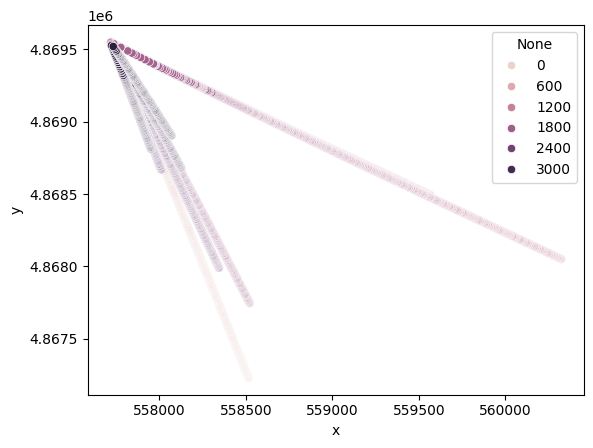

In [23]:
sns.scatterplot(pk_nodes, x = 'x', y = 'y', hue = pk_nodes.index)

<Axes: xlabel='0', ylabel='1'>

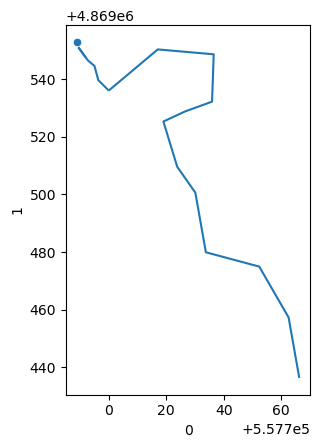

In [665]:
cave_data = gpd.read_file('../../data/cave_data/cave_Stickl.shp')
cave_data = cave_data.to_crs(config.crs)
cave_data.plot()
G = nx.Graph()
for geom in cave_data.geometry:
    coords = list(geom.coords)
    for i in range(len(coords)-1):
        G.add_edge(coords[i], coords[i+1])
sns.scatterplot(spring, x = 0, y = 1)


In [622]:
cave_nodes = pd.DataFrame(list(G.nodes), columns = ['x', 'y']).reset_index(names = 'id')

In [623]:
node_map = {node: i for i, node in enumerate(list(G.nodes))}
cave_edges = pd.DataFrame(([node_map[u], node_map[v]] for u, v in list(G.edges)),columns = ['to_id', 'from_id'])

In [624]:
cave_nodes.to_csv('../../data/cave_data/nodes.csv', index = False)
cave_edges.to_csv('../../data/cave_data/edges.csv', index = False)

In [3]:
cave_nodes = pd.read_csv('../../data/cave_data/nodes.csv')
cave_edges = pd.read_csv('../../data/cave_data/edges.csv')

<Axes: xlabel='x', ylabel='y'>

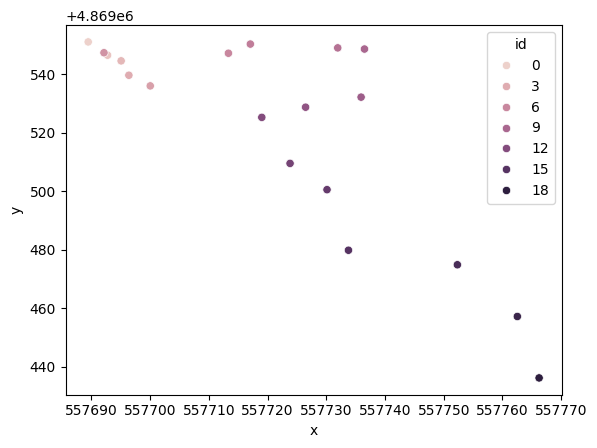

In [73]:
sns.scatterplot(cave_nodes, x = 'x', y ='y', hue = 'id')

In [462]:
network_path = '../../data/networks/output_dye_trace'

In [463]:
network_agg = None
n = 0
for f in os.listdir(network_path):
    # if int(f) < 11:
    #     continue
    n+=1
    network_dir = f'{network_path}/{f}/network.npy'
    network = np.load(network_dir)
    if network_agg is None:
        network_agg = network
    else:
        network_agg += network
network_agg /= n
network_agg = np.where(network_agg == 0, np.nan, network_agg)

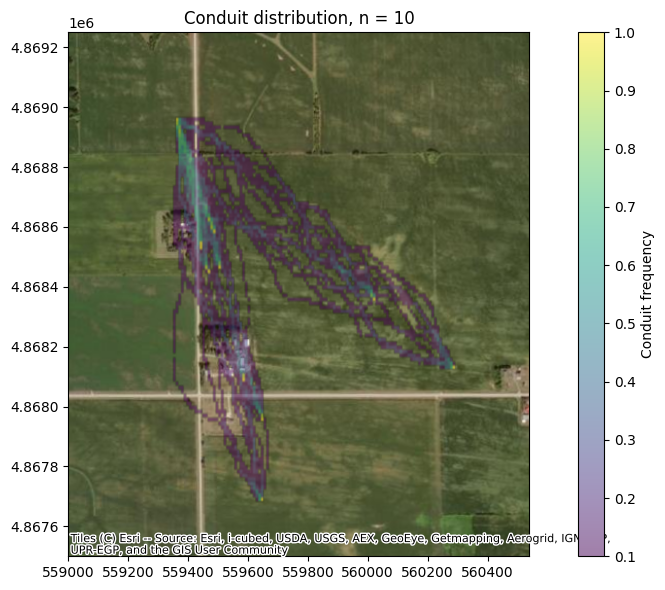

In [484]:
fig, ax = plt.subplots(figsize = (10,6))


# plt.colorbar(label = "Conduit frequency")
plt.title(f"Conduit distribution, n = {n}")
source = cx.providers.Esri.WorldImagery
im = ax.imshow(
    network_agg,
    extent=(config.total_bounds[0], config.total_bounds[2], config.total_bounds[1], config.total_bounds[3]),
    alpha=0.5,
    zorder = 2
)
# sns.scatterplot(ax = ax, data = nodes[nodes.type == 'outfall'], x= 'x', y ='y', color = 'blue', label = 'spring')
cx.add_basemap(
    ax, 
    crs=config.crs, 
    source=source, 
    zoom="auto"
)
ax.set_xlim(559000,)
ax.set_ylim(4.8675e6, 4.86925e6)
plt.colorbar(mappable = im, ax=ax, label = "Conduit frequency")
plt.tight_layout()


In [7]:
# network_dir = f'{network_path}'
network_dir = '../../data/cave_data'
nodes = pd.read_csv(f'{network_dir}/nodes.csv')
edges = pd.read_csv(f'{network_dir}/edges.csv')
# network = np.load(f'{network_dir}/network.npy')

In [8]:
valid_nodes = nodes[nodes.id >= 7]
node_set = set(valid_nodes.id)
valid_edges = edges[edges.from_id.isin(node_set) & edges.to_id.isin(node_set)]
offset = valid_nodes.id.min()
nodes_map = {id: id - offset for id in valid_nodes.id}
valid_nodes['id'] = valid_nodes['id'].map(nodes_map)
valid_edges['from_id'] = valid_edges['from_id'].map(nodes_map)
valid_edges['to_id'] = valid_edges['to_id'].map(nodes_map)
valid_nodes['type'] = valid_nodes['type'].replace('junction_outfall', 'outlet')
valid_edges = valid_edges.reset_index(drop = True)
valid_nodes = valid_nodes.reset_index(drop = True)

C:\Users\huan1428\AppData\Local\Temp\ipykernel_26840\4066702970.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\huan1428\AppData\Local\Temp\ipykernel_26840\4066702970.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\huan1428\AppData\Local\Temp\ipykernel_26840\4066702970.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

In [9]:
edges['y_0'] = nodes.iloc[edges.from_id].reset_index().y
edges['y_1'] = nodes.iloc[edges.to_id].reset_index().y
edges['x_0'] = nodes.iloc[edges.from_id].reset_index().x
edges['x_1'] = nodes.iloc[edges.to_id].reset_index().x
edges['z_0'] = nodes.iloc[edges.from_id].reset_index().z
edges['z_1'] = nodes.iloc[edges.to_id].reset_index().z

lines = edges[["x_0", "y_0", "z_0", "x_1", "y_1", "z_1"]].values
lines = lines.reshape(-1, 2, 3)


In [10]:

import plotly.graph_objects as go
line_traces = []
for line in lines:
    line_traces.append(
        go.Scatter3d(
            x=line[:,0],
            y=line[:,1],
            z=line[:,2],
            mode='lines',
            line=dict(color='blue', width=1),
            showlegend=False
        )
    )
node_type_map = {cat: i for i, cat in enumerate(nodes.type.unique())}
node_colors = nodes.type.map(node_type_map)
# Scatter for nodes
scatter = go.Scatter3d(
    x=nodes.x,
    y=nodes.y,
    z=nodes.z,
    mode='markers',
    marker=dict(
        size=5,
        color=node_colors,  # categorical or numeric
        colorscale='Viridis',
        showscale=True
    )
)

# Combine and plot
fig = go.Figure(data=line_traces + [scatter])
fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

In [11]:
%load_ext autoreload
%autoreload 2
loader = cdl.CaveDataLoader(nodes = nodes, edges = edges )
geometry = loader.load_cave_data(d = 1)

In [12]:
inlets, outlets = loader.extract_boundary_nodes()

In [88]:
time_start = pd.Timestamp('2018-05-02').dayofyear
time_end = pd.Timestamp('2018-06-14').dayofyear
config.load_polygon('watershed', 'springshed', 'subdomain')
# config.merge_polygons('merged', 'watershed_polygon', 'springshed_polygon')
config.set_domain('springshed_polygon')
total_area = config.domain.area[0] #in m
config.extract_recharge()
vol_recharge = {ts : rech * total_area/86400 for ts, rech in config.rech.items()} #in m^3/s
Q_per_inlet = {ts : rech/len(inlets) for ts, rech in vol_recharge.items()}
Q_limited_range = [v for k,v in Q_per_inlet.items() if time_start <= k <= time_end]

Q_per_inlet_seconds = np.concatenate([np.full(86400, Q) for Q in Q_limited_range])
Q_steady_state = np.array(list(Q_per_inlet.values())).mean()

<Axes: >

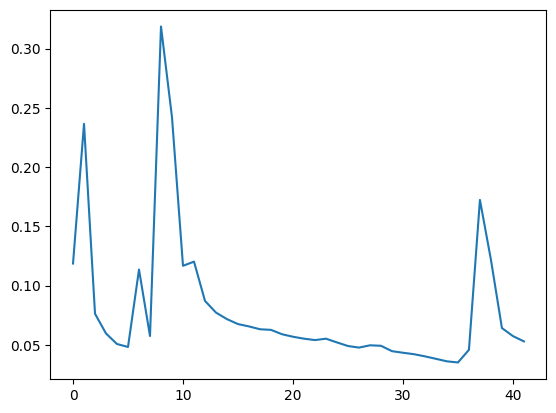

In [26]:
sns.lineplot(Q_limited_range)

In [391]:
Q_in_df = pd.DataFrame.from_dict(Q_per_inlet, orient = 'index', columns = ['Q'])
Q_in_baseflow = Q_in_df.rolling(window=7).mean().mean()[0]
Q_steady_state = Q_in_df[Q_in_df.Q <= Q_in_baseflow]['Q'].mean()

Text(0, 0.5, 'Spring discharge (m3/s)')

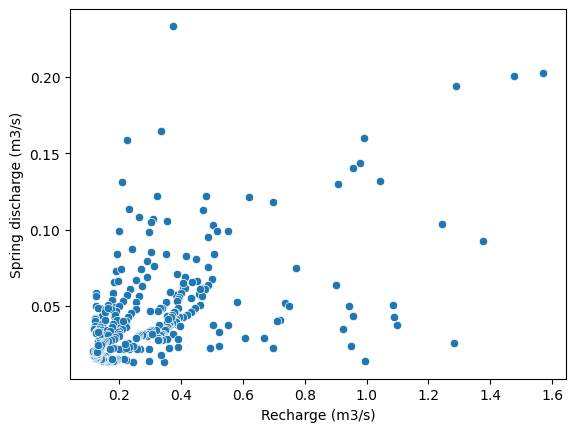

In [175]:
sns.scatterplot( x = Q_per_inlet.values(), y = bs_Q['m3/s'])
plt.xlabel("Recharge (m3/s)")
plt.ylabel("Spring discharge (m3/s)")

In [176]:
config.extract_grid_params_from_domain()
config.extract_bottom_config()

In [177]:
bs_Q = pd.read_csv(config.calibration_data[0]['data'])
bs_Q = convert_df_to_datetime(bs_Q, 'datetime')
bs_Q['m3/s'] = bs_Q['m3/d']/86400


In [178]:
baseflow_cutoff = bs_Q['m3/s'].rolling(window = 7).mean().mean()
bs_Q_ss = bs_Q[bs_Q['m3/s'] <= baseflow_cutoff]['m3/s'].mean()

<Axes: xlabel='datetime', ylabel='m3/s'>

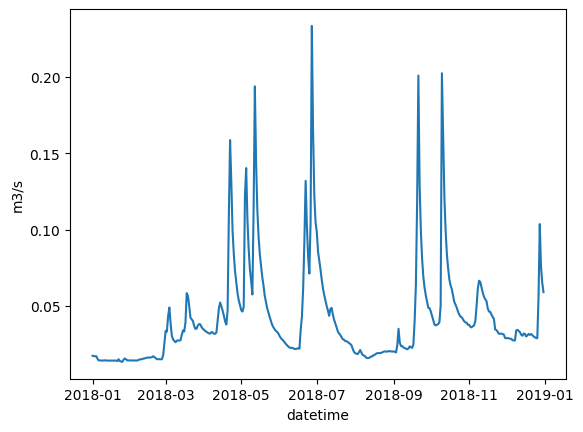

In [179]:
sns.lineplot(bs_Q, x = 'datetime', y = 'm3/s')

In [633]:
nodes[['row', 'col']] = pd.DataFrame(
    [config.get_cell_id_from_coords(x, y) for x, y in zip(nodes.x, nodes.y)],
    index=nodes.index)

In [634]:
nodes['elev'] = config.botm_elev[0][list(nodes.row), list(nodes.col)]


In [635]:
nodes['z'] = nodes['elev'] - nodes.elev.min()
nodes[['id', 'x', 'y', 'z', 'type']].to_csv(f'{network_dir}/nodes.csv', index = False)

In [27]:
def main(geometry, base_dir = '.', inlets = [], outlets = [], cn_params = None, flowrate = 0, water_depth = 0.01, inlets_boundary = {'flow' : 0.01}, outlets_boundary ={'head' : 0.1}, steady_state = True, t_max = 1000, dt = 1, inflow_type = 'constant', end_time = 3600):
    
    # base_dir = os.path.dirname(os.path.abspath(__file__))
    
    # Setup flow simulation parameters
    physical_properties = {
        'water_density': 1000,        # kg/m^3
        'gravity': 9.81,              # m/s^2
        'dynamic_viscosity': 0.001,   # Pa.s (kg/m.s)
        'geometry_channel': False,    # Channel geometry for analytical solutions (Default False)
        'channel_type': 'infinite',   # 'infinite' for infinitely wide channel, 'finite' for defined width
        'channel_width': 1.0,         # Width of the channel (only used if channel_type is 'finite')
    }
    
    solver_settings = {
        'relaxation_factor': 0.6,    # Dimensionless
        'max_iterations': 20,        # Maximum Picard iterations
        'picard_depth_tol': 1e-7,    # Picard depth tolerance (meters)
        'ss_rel_l2tol': 1e-3,         # L2 tolerance for steady-state
        'ss_rel_madtol': 1e-8         # Median tolerance for steady-state
    }
    
    simulation_settings = {
        'min_waterdepth': 1e-10,      # Minimum water depth (meters)
        'min_flowrate': 1e-10,        # Minimum flow rate (m^3/s)
        'courant': 0.8,               # Courant number
        'adaptive_timesteps': True,   # Use adaptive timestepping
        'dt_init': dt,             # Initial (or constant) timestep (seconds)
        'dt_max': 1.0,                # Maximum allowable time step
        'steady_state': steady_state,         # Steady-state (True) or transient (False)
        't_max': t_max,              # Maximum time for transient simulations (seconds)
        'print_info_interval': 1000,     # Print info every # time steps
    }
    
    output_settings = {
        'output_interval': 10.0,
        'time': True,
        'time_step_size': True,
        'flowrates': True,
        'water_depths': True,
        'l2_norms': True,
        'convergence_fails': True,
        'reynolds_numbers': True,
    }
    
    logging_settings = {
        'base_dir': base_dir,
        'log_file': 'simulation.log'
    }
    
    # Create network object using OpenPNM
    dl = 1 # Constant spacing between nodes (meters)
    cn_geometry = geometry
    
    # Compute conduit lengths using the utility function
    cn_geometry = compute_conduit_lengths(cn_geometry)
    
    # Assign conduit properties
    for param, val in cn_params.items():
        print(param)
        cn_geometry[param] = val
    
    if inflow_type == 'timeseries':
        simulation_settings['adaptive_timesteps'] = False
    # Create flow network object
    flow_network = FlowSimulation(cn_geometry,
                                  physical_properties = physical_properties,
                                  solver_settings = solver_settings,
                                  simulation_settings = simulation_settings,
                                  logging_settings = logging_settings)
    
    # Set initial conditions
    initial_Q = np.full(cn_geometry.Nt, flowrate, dtype=float)   # Initial flows at each conduit (Nt throats)
    initial_y = np.full(cn_geometry.Np, water_depth, dtype=float)  # Initial water depths at each node (Np pores)    
    flow_network.set_initial_conditions(initial_Q, initial_y)
    
    # Set boundary conditions
    inflow_boundary = {}
    waterdepth_boundary = {}
    if 'flow' in inlets_boundary:
        if inflow_type == 'ramp':
            inflow_boundary.update({node: ('volumetric', (inlets_boundary['flow'], 10 * inlets_boundary['flow'])) for node in inlets})
        else:
            inflow_boundary.update({node: ('volumetric', inlets_boundary['flow']) for node in inlets})
    else: 
        waterdepth_boundary.update({node: inlets_boundary['head'] for node in inlets})
    if 'flow' in outlets_boundary:
        inflow_boundary.update({node: ('volumetric', outlets_boundary['flow']) for node in outlets})
    else: 
        waterdepth_boundary.update({node: outlets_boundary['head'] for node in outlets})
    print(inflow_boundary)


    flow_network.set_boundary_conditions(
    inflow_boundary=inflow_boundary,
    waterdepth_boundary=waterdepth_boundary,
    inflow_type=inflow_type,
    end_time= end_time)

    # Run simulation and store results
    results = flow_network.run_simulation(desired_outputs = output_settings)
    
    # Get arrays from results container
    Q_history = results['flowrates']
    y_history = results['water_depths']
    t_history = results['time']
    
    
    animation_settings = {
        'update_interval': 1,
        'conduit_plotradius': 0.5,
        'bar_plotradius': 0.5,
        'node_plotsize': 5,
        'depthscaling': 20,
        'fig_width': 1600,
        'fig_height': 800,
        'zoom_factor': 1.0,
        'background_color': 'black',
        'isometric_view': False,
        'create_animation': False,
        'filename': "network_animation2.mp4"
    }
    
    animate_network(cn_geometry=cn_geometry, 
                    Q_history=Q_history, 
                    y_history=y_history, 
                    t_history=t_history, 
                    **animation_settings)
    return results


In [ ]:
#ramp
%load_ext autoreload
%autoreload 2
results = main(geometry, inlets = inlets, outlets = outlets, cn_params = {'throat.epsilon' : 0.03}, inlets_boundary= {'flow' : .02}, outlets_boundary= {'head' : 0.01}, steady_state = False, flowrate = 0.02, water_depth=0.01, t_max = 3600, dt= 1, inflow_type = 'ramp')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
throat.epsilon
{11: ('volumetric', (0.02, 0.2))}
New dt = 5.23e-02 Max Froude = 58.77
Timestep = 0, Time = 0.0, i = 0
Max Re = 99832.86 Avg Re = 99832.86

New dt = 9.27e-02 Max Froude = 32.70
Timestep = 0, Time = 0.0, i = 1
Max Re = 55544.36 Avg Re = 55504.61

New dt = 1.34e-01 Max Froude = 22.36
Timestep = 0, Time = 0.0, i = 2
Max Re = 38087.81 Avg Re = 37978.35

New dt = 1.62e-01 Max Froude = 18.33
Timestep = 0, Time = 0.0, i = 3
Max Re = 31708.41 Avg Re = 31156.46

New dt = 1.76e-01 Max Froude = 16.78
Timestep = 0, Time = 0.0, i = 4
Max Re = 29491.50 Avg Re = 28560.53

New dt = 1.82e-01 Max Froude = 16.19
Timestep = 0, Time = 0.0, i = 5
Max Re = 28809.38 Avg Re = 27593.25

New dt = 1.83e-01 Max Froude = 15.98
Timestep = 0, Time = 0.0, i = 6
Max Re = 28649.59 Avg Re = 27250.67

New dt = 1.83e-01 Max Froude = 15.93
Timestep = 0, Time = 0.0, i = 7
Max Re = 28682.54 Avg Re = 27179.32

New dt = 1.83e-

Widget(value='<iframe src="http://localhost:64574/index.html?ui=P_0x18773252db0_23&reconnect=auto" class="pyvi…

In [ ]:
#steady state
%load_ext autoreload
%autoreload 2
Q_in = Q_steady_state *30
results = main(geometry, inlets = inlets, outlets = outlets, cn_params = {'throat.epsilon' : 0.03}, inlets_boundary= {'flow' :Q_in}, outlets_boundary= {'head' : 0.01}, steady_state = True, water_depth=0.1, t_max = 1000, dt = 0.1, inflow_type = 'constant')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
throat.epsilon
{18: ('volumetric', np.float64(1.2933829586201533))}
New dt = 1.00e+00 Max Froude = 0.00
Timestep = 0, Time = 0.0, i = 0
Max Re = 0.00 Avg Re = 0.00

New dt = 5.40e-01 Max Froude = 0.81
Timestep = 0, Time = 0.0, i = 1
Max Re = 42175.67 Avg Re = 4613.14

New dt = 4.75e-01 Max Froude = 1.06
Timestep = 0, Time = 0.0, i = 2
Max Re = 55007.58 Avg Re = 8210.47

New dt = 5.57e-01 Max Froude = 0.78
Timestep = 0, Time = 0.0, i = 3
Max Re = 39239.07 Avg Re = 11779.97

New dt = 4.59e-01 Max Froude = 1.13
Timestep = 0, Time = 0.0, i = 4
Max Re = 58650.58 Avg Re = 18995.14

New dt = 5.09e-01 Max Froude = 0.84
Timestep = 0, Time = 0.0, i = 5
Max Re = 50952.64 Avg Re = 23697.72

New dt = 4.70e-01 Max Froude = 1.09
Timestep = 0, Time = 0.0, i = 6
Max Re = 56070.16 Avg Re = 25020.77

New dt = 5.03e-01 Max Froude = 0.82
Timestep = 0, Time = 0.0, i = 7
Max Re = 52347.80 Avg Re = 24519.76

New dt = 4.69e

Widget(value='<iframe src="http://localhost:64574/index.html?ui=P_0x187732097f0_43&reconnect=auto" class="pyvi…

In [39]:
#timeseries
%load_ext autoreload
%autoreload 2
results = main(geometry, inlets = inlets, outlets = outlets, cn_params = {'throat.epsilon' : 0.03}, inlets_boundary= {'flow' :Q_per_inlet_seconds}, outlets_boundary= {'head' : 0.01}, steady_state = False, water_depth=0.1, t_max = 86400*30, dt = 1, inflow_type = 'timeseries')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
throat.epsilon
{18: ('volumetric', array([0.11864395, 0.11864395, 0.11864395, ..., 0.05294835, 0.05294835,
       0.05294835]))}
New dt = 1.00e+00 Max Froude = 0.00
Timestep = 0, Time = 0.0, i = 0
Max Re = 0.00 Avg Re = 0.00

New dt = 1.00e+00 Max Froude = 0.81
Timestep = 0, Time = 0.0, i = 1
Max Re = 42175.67 Avg Re = 4580.49

New dt = 1.00e+00 Max Froude = 1.34
Timestep = 0, Time = 0.0, i = 2
Max Re = 69665.12 Avg Re = 10070.76

New dt = 1.00e+00 Max Froude = 1.12
Timestep = 0, Time = 0.0, i = 3
Max Re = 58002.45 Avg Re = 15503.15

New dt = 1.00e+00 Max Froude = 1.05
Timestep = 0, Time = 0.0, i = 4
Max Re = 53970.28 Avg Re = 23103.95

New dt = 1.00e+00 Max Froude = 1.03
Timestep = 0, Time = 0.0, i = 5
Max Re = 52900.92 Avg Re = 25437.30

New dt = 1.00e+00 Max Froude = 1.03
Timestep = 0, Time = 0.0, i = 6
Max Re = 52767.35 Avg Re = 25531.81

New dt = 1.00e+00 Max Froude = 1.03
Timestep = 0, Time = 

Widget(value='<iframe src="http://localhost:53790/index.html?ui=P_0x2660cf58830_3&reconnect=auto" class="pyvis…

In [40]:
Q = results['flowrates']
t = results['time']
y = results['water_depths']

In [ ]:
# nodes = valid_nodes
# edges = valid_edges

In [51]:
outflow_node_ids = nodes[(nodes.type=='outfall') | (nodes.type == 'outlet')].id

In [60]:
y.shape

(259200, 19)

Text(0.5, 1.0, 'Spring discharge')

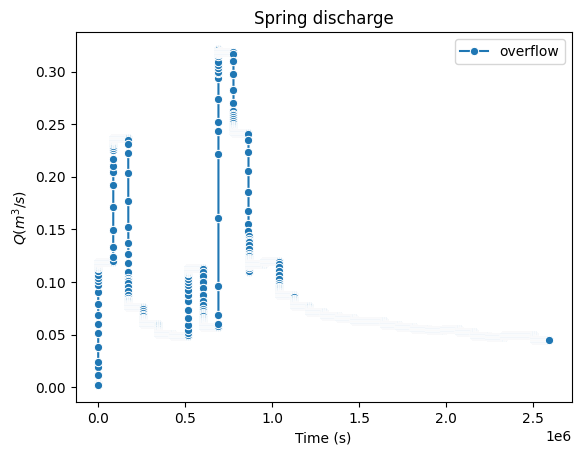

In [50]:
label_map = {0 : 'overflow', 19 : 'bear spring'}
for node in outflow_node_ids:
    edges_loc = edges[(edges.to_id == node) | (edges.from_id == node)].index
    outlet_Q = 0
    for edge in edges_loc:
        outlet_Q += Q[:, edge]
    outlet_Q = outlet_Q * -1
    sns.lineplot(x = t, y = outlet_Q, label = label_map[node], marker = 'o')
plt.ylabel(r"$Q (m^3/s)$")
plt.xlabel("Time (s)")
plt.title("Spring discharge")

In [79]:
bs_q_real = pd.read_csv('../../data/discharge/single_peak_05_01_2018.csv')
bs_q_real['m3/s'] = bs_q_real['m3/d']/86400
bs_q_real = convert_df_to_datetime(bs_q_real, 'datetime')

<Axes: xlabel='datetime', ylabel='m3/s'>

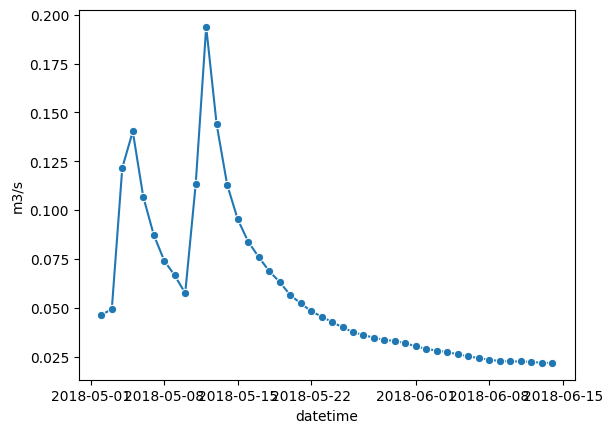

In [82]:
sns.lineplot(bs_q_real, x = 'datetime', y = 'm3/s', marker = 'o')

In [83]:
ok_q = pd.read_csv("single_peak_Q.csv")
ok_q['datetime'] = pd.to_datetime('2018-05-02') + pd.to_timedelta(ok_q['t'], unit='s')

np.float64(2.2331322236050535)

Text(0.5, 1.0, 'Observed and modeled spring discharge')

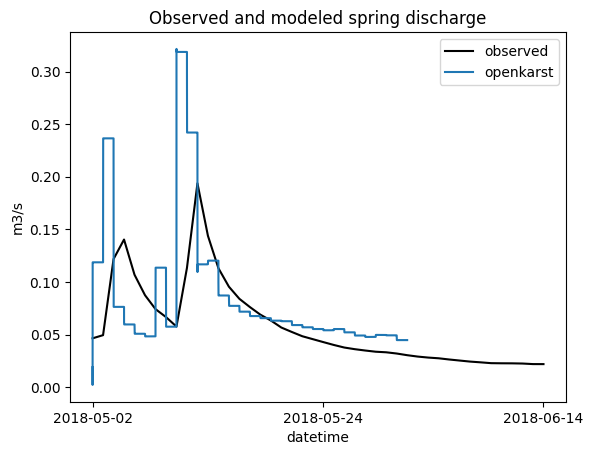

In [100]:
sns.lineplot(bs_q_real, x = 'datetime', y = 'm3/s', label = 'observed', color = 'black')
sns.lineplot(ok_q, x = 'datetime', y = ' Q', label = 'openkarst')
plt.xticks([bs_q_real.datetime[0],bs_q_real.datetime[len(bs_q_real.datetime)//2], bs_q_real.datetime[len(bs_q_real.datetime)-1]])  # first, middle, last
plt.title("Observed and modeled spring discharge")
# sns.lineplot(x = bs_q_real.datetime, y = Q_limited_range, label = 'recharge')

Text(0.5, 1.0, 'openKARST recharge and discharge')

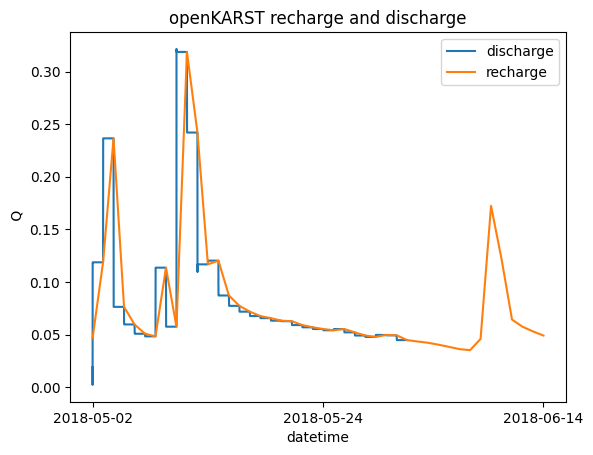

In [99]:
sns.lineplot(ok_q, x = 'datetime', y = ' Q', label = 'discharge')
sns.lineplot(x = bs_q_real.datetime, y = Q_limited_range, label = 'recharge')
plt.xticks([bs_q_real.datetime[0],bs_q_real.datetime[len(bs_q_real.datetime)//2], bs_q_real.datetime[len(bs_q_real.datetime)-1]])  # first, middle, last

plt.title("openKARST recharge and discharge")

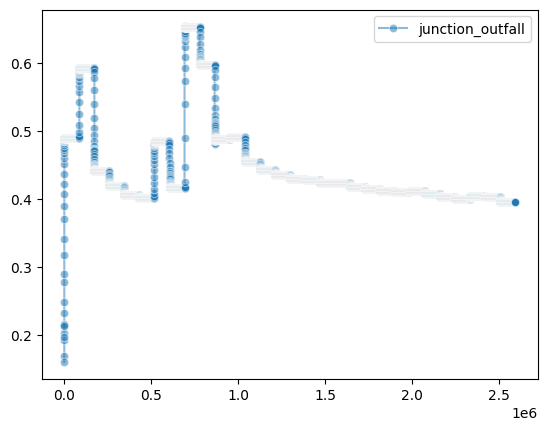

In [75]:
junction_node_ids = nodes[nodes.type=='junction_outfall'].id
for node in junction_node_ids:
    sns.lineplot(x = t, y = y[:, node], label = nodes.type[node], marker = 'o', alpha = 0.5)

In [55]:
edges['y_0'] = nodes.iloc[edges.from_id].reset_index().y
edges['y_1'] = nodes.iloc[edges.to_id].reset_index().y
edges['x_0'] = nodes.iloc[edges.from_id].reset_index().x
edges['x_1'] = nodes.iloc[edges.to_id].reset_index().x

Text(0.5, 1.0, 'Steady state flow distibution, $Q_{in}$ = 2.2331322236050535')

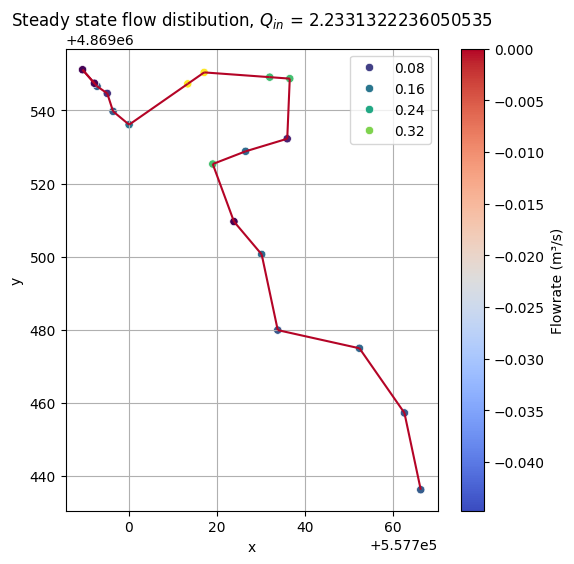

In [57]:
from matplotlib.collections import LineCollection
segments = edges[['x_0', 'y_0', 'x_1', 'y_1']].values.reshape(-1, 2, 2)
ts = len(Q)-1
# ts = 10
norm = plt.Normalize(vmin=Q[ts].min(), vmax=Q[ts].max())

# Get seaborn colormap
palette = sns.color_palette("coolwarm", as_cmap=True)

lc = LineCollection(segments, cmap=palette, norm=norm)
lc.set_array(Q[ts] * -1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.add_collection(lc)
ax.autoscale()  # Needed for LineCollection to be visible
sns.scatterplot(nodes, x = 'x', y = 'y', hue = y[ts], ax = ax, palette = 'viridis')
plt.colorbar(lc, ax=ax, label="Flowrate (m³/s)")
plt.grid(True)
plt.title(rf"Steady state flow distibution, $Q_{{in}}$ = {Q_in}")

# plt.title(f"Steady state flow distibution, t = {np.round(t[ts], 3)}")
# plt.ylim(4.869530e6)


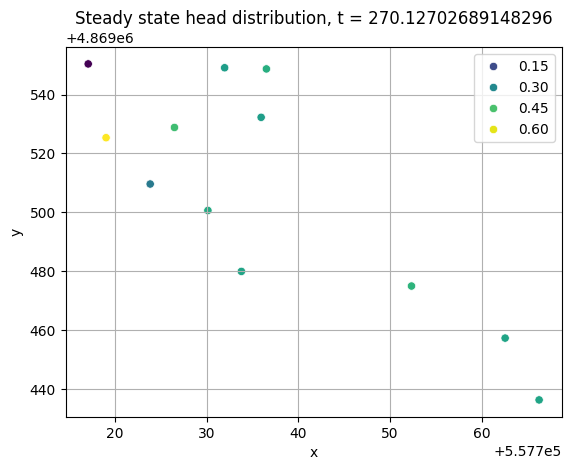

In [319]:
sns.scatterplot(nodes, x= 'x', y ='y', hue = y[ts], palette= 'viridis')
plt.title(f"Steady state head distribution, t = {t[ts]}")
plt.grid(True)


In [444]:
sinkholes = pd.read_csv('../../data/geo_data/bear_sinkholes_coords.txt', sep = ' ',header = None)
springs = pd.read_csv('../../data/geo_data/springs_coords.txt', sep = ' ', header = None)
springs = springs.rename({0 : 'x', 1 : 'y'}, axis = 1)
sinkholes = sinkholes.rename({0 : 'x', 1 : 'y'}, axis = 1)

<Axes: xlabel='x', ylabel='y'>

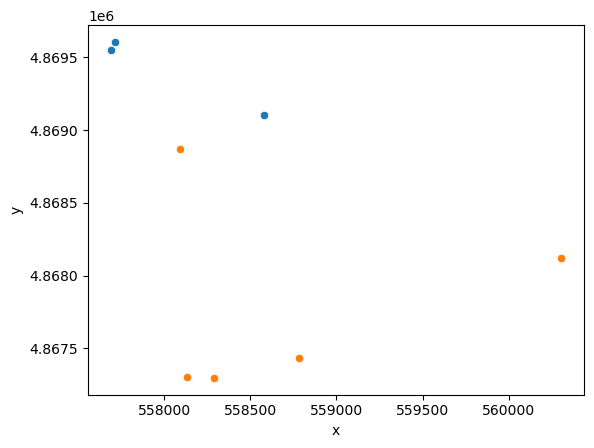

In [ ]:
sample = sinkholes.sample(5)
sns.scatterplot(springs, x= 'x', y ='y')
sns.scatterplot(sample, x = 'x', y = 'y')